**Asignatura**: Extensiones de Machine Learning, 2024/2025

**Alumnos**:<br>
- Salvador de Haro Orenes (salvadorde.haroo@um.es)
- Jose María Belmonte Martínez (josemaria.belmontem@um.es)
- Miguel Vidal García (miguel.vidalg@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)


# Estudio comparativo de algoritmos en un problema de k-armed bandit

En los apartados siguientes se realizan y analizan diferentes experimentos en el ámbito de la resolución del problema del bandido de k-brazos utilizando los algoritmos UCB1 y UCB2. Los experimentos se diferencian por el tipo de distribución de probabilidad asociada a los brazos del bandido (Normal, Bernoulli, Binomial).

En estos tres experimentos, cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado. Se comparan los resultados de los algoritmos en términos del valor promedio asociado a diferentes métricas de interés.

Por ejemplo, dado un bandido de k-brazos, se ejecutan los algoritmos UCB1 y UCB2 con diferentes valores de sus respectivos parámetros. Se estudia la evolución de cada política en un número de pasos, por ejemplo, mil pasos. Luego, se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso, se calculan los resultados promedio en esas 500 ejecuciones.

>Nota: Como ya se ha mencionado en el notebook **bandit_experiments_epsilongreedy**.ipynb, hemos seleccionado como métricas relevantes para el análisis: el porcentaje de selección del brazo óptimo y el rechazo acumulado. Por tanto, estos serán los gráficos utilizados para el estudio de los algoritmos UCB1 y UCB2.


## Preparación del entorno


### Copiar el repositorio

In [1]:
# Clonar el repositorio en Google Colab
!git clone https://github.com/salvadeharo10/k_brazos_DHBV.git
%cd k_brazos_DHBV

# Confirmar clonación exitosa
print("✅ Repositorio clonado con éxito.")

Cloning into 'k_brazos_DHBV'...
remote: Enumerating objects: 459, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 459 (delta 43), reused 3 (delta 2), pack-reused 394 (from 2)
Receiving objects: 100% (459/459), 19.63 MiB | 33.72 MiB/s, done.
Resolving deltas: 100% (298/298), done.
/content/k_brazos_DHBV
✅ Repositorio clonado con éxito.


In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos_DHBV/src')

# Verificar que se han añadido correctamente
print(sys.path)


['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython', '/content/k_brazos_DHBV/src']


In [3]:
import numpy as np
from typing import List

from algorithms import Algorithm, UCB1, UCB2
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

### Configuración de semilla para reproducibilidad de los experimentos

In [4]:
SEED = 1234
np.random.seed(SEED)

A continuación, se defien los hiperparámetros de los experimentos, tales como el número de brazos del bandido, el número de pasos temporalesq que ejecutarán cada algoritmo y el número de veces que se repetirá el experimento.

In [5]:
# Parámetros de los experimentos
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Experimentos para la familia de algoritmos UCB1

Ahor se define una función genérica denominada `run_experiment_ucb1`, que se usará para la realización de los distintos experimentos.

Para implementar el algoritmo se define una clase `ucb1` que hereda de la clase `Algorithm`, y se implementa la política de selección de brazo de este algoritmo. La ecuación para determinar la recompensa esperada es:

$$
\text{UCB1}(a) = Q(a) + c \times \sqrt{\frac{\ln t}{N_t(a)}}
$$
donde $c$ el parámetro de ajuste que controla el grado de exploración


In [6]:
def run_experiment_ucb1(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Realiza simulaciones de un problema k-arm bandit con diferentes estrategias.

    :param bandit: Instancia del entorno de bandit.
    :param algorithms: Lista de algoritmos a evaluar.
    :param steps: Número de iteraciones en cada simulación.
    :param runs: Número de veces que se repite la simulación para promediar resultados.
    """
    optimal_arm = bandit.optimal_arm  # Índice del mejor brazo.

    optimal_picks = np.zeros((len(algorithms), steps))  # Registro de elecciones óptimas.
    regret = np.zeros((len(algorithms), steps))  # Registro de regret acumulado.


    for run in range(runs):
        simulation_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset()  # Restablecer valores del algoritmo antes de cada ejecución.

        step = 0
        while step < steps:
            for idx, algo in enumerate(algorithms):
                if step < k: #inicializaciones iniciales (k actualizaciones, es decir, k pasos de tiempo)
                    selected_arm = step
                    reward = simulation_bandit.pull_arm(selected_arm)
                    algo.update(selected_arm, reward)
                    # Registrar selecciones óptimas y rechazos
                    optimal_picks[idx, step] += (selected_arm == optimal_arm)
                    regret[idx, step] += simulation_bandit.get_expected_value(optimal_arm) - simulation_bandit.get_expected_value(selected_arm)
                else:
                    selected_arm = algo.select_arm(step)
                    reward = simulation_bandit.pull_arm(selected_arm)
                    algo.update(selected_arm, reward)
                    # Registrar selecciones óptimas y rechazos
                    optimal_picks[idx, step] += (selected_arm == optimal_arm)
                    regret[idx, step] += simulation_bandit.get_expected_value(optimal_arm) - simulation_bandit.get_expected_value(selected_arm)

            step += 1

    # Promediar resultados sobre todas las simulaciones
    regret /= runs
    optimal_picks /= runs
    optimal_picks *= 100  # Convertir en porcentaje


    return optimal_picks, regret

## Experimento UCB1 con brazos que siguen una distribución de probabilidad normal

Se realiza el experimento utilizando 10 brazos. El experimento consta de 500 ejecuciones, cada una con 1000 pasos. Se contrastan 3 variantes del algoritmo UCB1 para los siguientes valores de $c$ : 1, 5 y 0.1.
- El parámetro $c$ es un ajuste que controla el grado de exploración del algoritmo (valor por defecto $c$ = 1).


In [7]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k), UCB1(k=k, c=5), UCB1(k=k, c=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections_n, regret_n = run_experiment_ucb1(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=2.72, sigma=1.0), ArmNormal(mu=3.45, sigma=1.0), ArmNormal(mu=4.94, sigma=1.0), ArmNormal(mu=3.49, sigma=1.0), ArmNormal(mu=6.6, sigma=1.0), ArmNormal(mu=8.07, sigma=1.0), ArmNormal(mu=8.02, sigma=1.0), ArmNormal(mu=8.22, sigma=1.0), ArmNormal(mu=9.62, sigma=1.0), ArmNormal(mu=8.88, sigma=1.0)
Optimal arm: 9 with expected reward=9.62


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

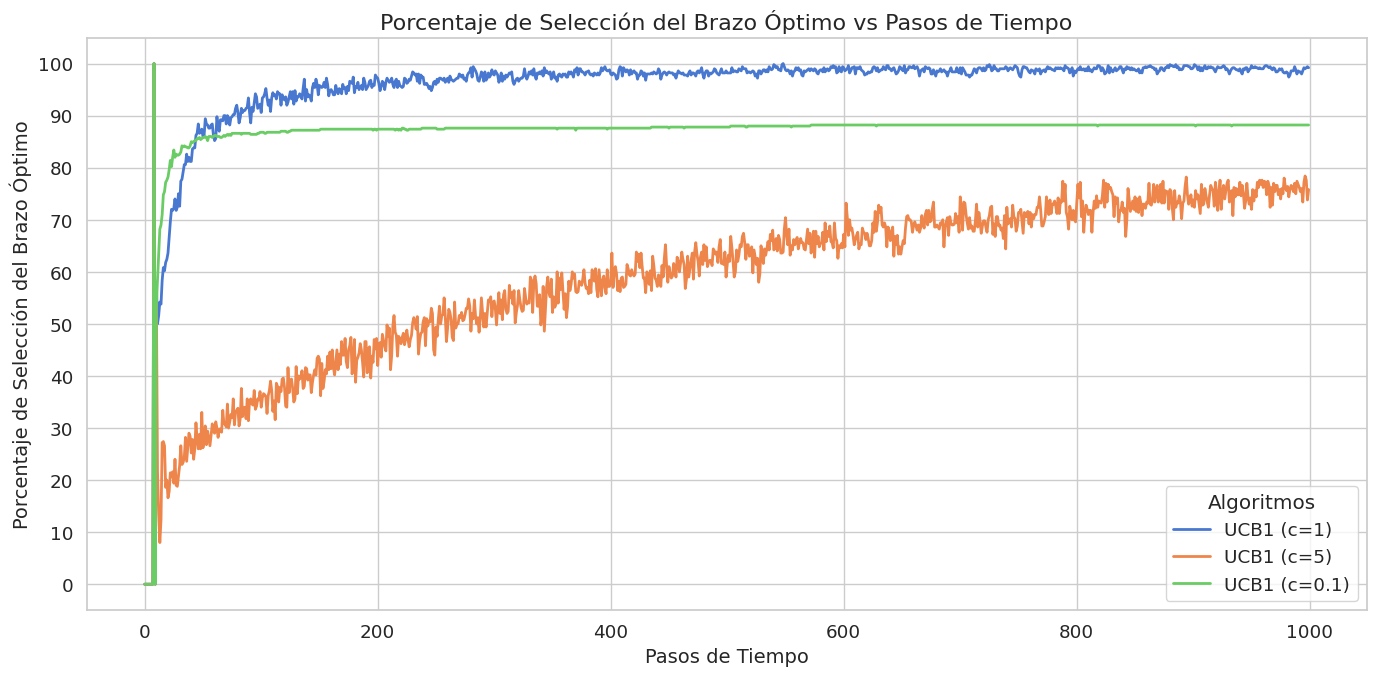

In [8]:
plot_optimal_selections(steps, optimal_selections_n, algorithms)

**Análisis**

La imagen muestra un gráfico donde se analiza el rendimiento de diferentes variantes del algoritmo **UCB1** en un entorno de **multi-armed bandit**.

---

**1. Cómo afectan los distintos valores de $c$**

- **Azul ($c$ = 1)**
  - **Balance moderado entre exploración y explotación**.
  - Se observa que, con el tiempo, el algoritmo **converge** de forma estable hacia el brazo óptimo y mantiene un alto porcentaje de selección de dicho brazo.

- **Naranja ($c$ = 5)**
  - **Más énfasis en la exploración** debido a un valor de $c$ grande.
  - Se ve un crecimiento progresivo en la selección del brazo óptimo, pero tarda más en “confiar” y explotar el mejor brazo, pues continúa probando otros para reducir la incertidumbre.
  - **Convergencia más lenta** al brazo óptimo; sin embargo, a largo plazo, parece que también acaba mejorando su rendimiento.

- **Verde ($c$ = 0.1)**
  - **Menor énfasis en la exploración**, por lo que se explota antes el brazo que parezca bueno.
  - Si el algoritmo identifica rápido el mejor brazo, sube rápido el porcentaje de selección. Pero si el arranque es desafortunado y el brazo elegido no es realmente óptimo, puede quedarse “atascado” por falta de exploración.
  - En el gráfico se observa que alcanza un porcentaje cercano al 90%: ha encontrado un brazo bueno, pero el **poco margen de exploración** puede impedirle mejorar.


**2. Interpretación de los resultados**

- **La exploración es clave para el aprendizaje**  
  - Un $c$ demasiado bajo puede hacer que el algoritmo se **quede con un brazo subóptimo** si la suerte inicial no acompaña.  
  - Un $c$ demasiado alto  puede ralentizar la **convergencia** al mejor brazo, pues sigue probando otros incluso cuando ya hay evidencia suficiente de que uno es mejor.
  - Un $c$ moderado como: $c$ = 1 suele lograr **encontrar y explotar** el mejor brazo con mayor rapidez y estabilidad.
  - En teoría, **UCB1** con cualquier \(c > 0\) **termina concentrándose** en el mejor brazo conforme el número de pasos de tiempo crece, pero la **velocidad de convergencia** depende fuertemente de \(c\).

---

#### Rechazo acumulado a lo largo del tiempo


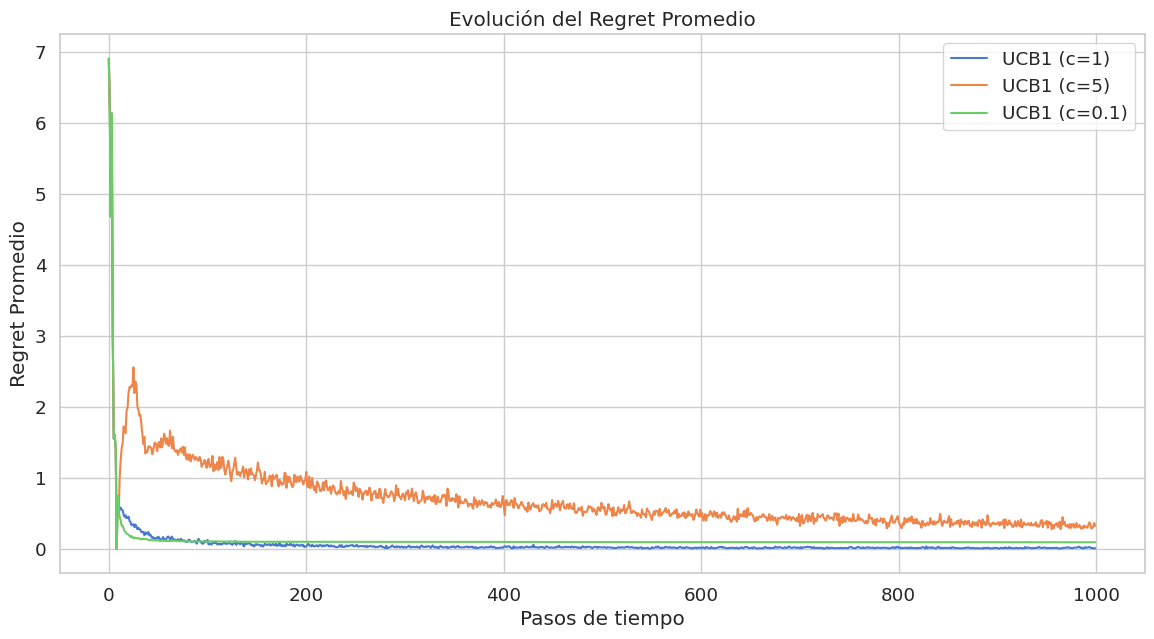

In [9]:
plot_regret(steps, regret_n, algorithms)

**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función de los pasos de tiempo para el algoritmo **UCB1** con tres valores distintos del parámetro $c$:

---

**Para \($c$ = 0.1\) – Baja Exploración**

- **Baja exploración**: Con \(c = 0.1\), el algoritmo enfatiza la explotación sobre la exploración.
- Puede presentar un **pico inicial de regret** si las primeras estimaciones no son favorables.
- Sin embargo, si identifica rápidamente el brazo óptimo, el regret **disminuye de forma pronunciada**, resultando en un **regret acumulado final bajo**.



**Para \($c$ = 5\) – Alta Exploración**

- **Alta exploración**: Con \(c = 5\), el algoritmo valora fuertemente la incertidumbre, lo que lleva a seleccionar brazos menos explorados incluso cuando se evidencia cuál es el mejor.
- Esto causa que el **regret acumulado se mantenga alto** durante un mayor número de iteraciones, ya que se siguen eligiendo brazos subóptimos para reducir la incertidumbre.
- Aunque esta estrategia puede prevenir quedarse atrapado en una mala decisión, su coste es un **regret más elevado a largo plazo**.



**Para  \($c$ = 1\) – Exploración Equilibrada**

- **Balance moderado**: Con \(c = 1\), el algoritmo mantiene un equilibrio entre explorar nuevas opciones y explotar el brazo óptimo.
- El regret inicial es menor que en el caso de \(c = 5\) y converge de forma estable a un **valor bajo**.
- Esta configuración ofrece un **compromiso adecuado** para identificar y aprovechar el mejor brazo sin explorar en exceso.







## Experimento UCB1 con brazos que siguen una distribución de probabilidad binomial

In [10]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n = 10, seed = SEED)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k), UCB1(k=k, c=5), UCB1(k=k, c=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections_bi, regret_bi = run_experiment_ucb1(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.45), ArmBinomial(n=10, p=0.72), ArmBinomial(n=10, p=0.73), ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.74), ArmBinomial(n=10, p=0.87), ArmBinomial(n=10, p=0.8), ArmBinomial(n=10, p=0.39)
Optimal arm: 8 with expected reward=8.7


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

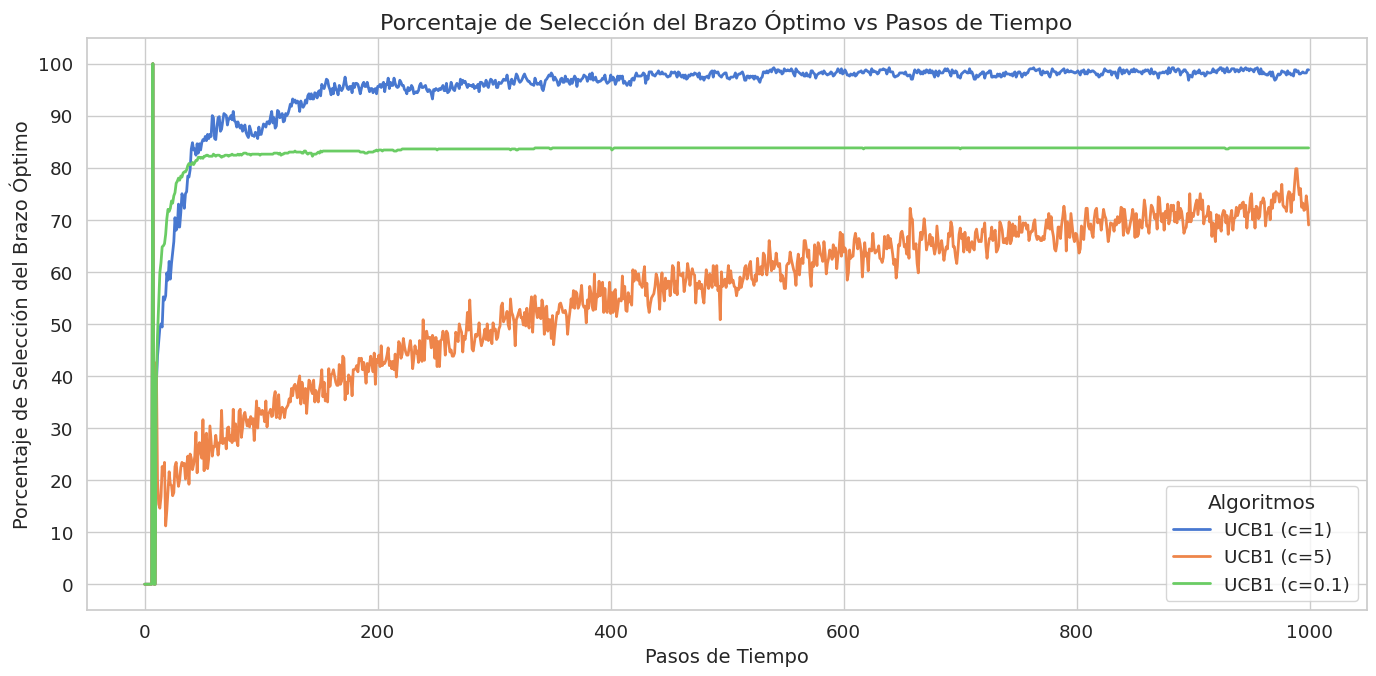

In [11]:
plot_optimal_selections(steps, optimal_selections_bi, algorithms)

**Análisis**

El gráfico muestra la evolución del **porcentaje de selección del brazo óptimo** en función del tiempo para tres configuraciones del algoritmo **UCB1** con diferentes valores del parámetro \( c \).

---

**1. Cómo afectan los distintos valores de $c$**  

- **Azul ($c$ = 1)**
  - Al inicio, el algoritmo explora distintos brazos, pero rápidamente converge hacia la selección del brazo óptimo.  
  - A medida que avanza el tiempo (en torno al paso 100), la selección del brazo óptimo supera el **90%** y se mantiene estable a medida que pasa el tiempo en valores cercanos al **100%**.  

- **Naranja ($c$ = 5)**
  - La selección del brazo óptimo crece de forma mucho más lenta en comparación con $c$ = 1.  
  - Aunque sigue aumentando con el tiempo, después de 1000 pasos todavía no alcanza la estabilidad de los otros algoritmos.  
  

- **Verde ($c$ = 0.1)**
  - Rápidamente alcanza un **80% de selección del brazo óptimo**, pero se mantiene en ese valor sin mejorar significativamente.  
  - Esto sugiere que **explora muy poco**, por lo que podría quedarse atrapado en un brazo que parece bueno pero no es el mejor.  
  - Su rendimiento es mejor que el de \( $c$ = 5 \) en el corto plazo, pero no logra alcanzar la efectividad del caso \( $c$ = 1 \).  

**2. Interpretación de los resultados**

**El equilibrio entre exploración y explotación es clave**  
- **valores medios de c logran la mejor convergencia**, ya que combina suficiente exploración inicial con una explotación eficiente del mejor brazo.  
- **valores bajos encuentra rápido un buen brazo**, pero no explora lo suficiente para asegurarse de que sea el óptimo.  
- **valores altos exploran demasiado**, retrasando el aprendizaje del mejor brazo.  



### Rechazo acumulado a lo largo del tiempo

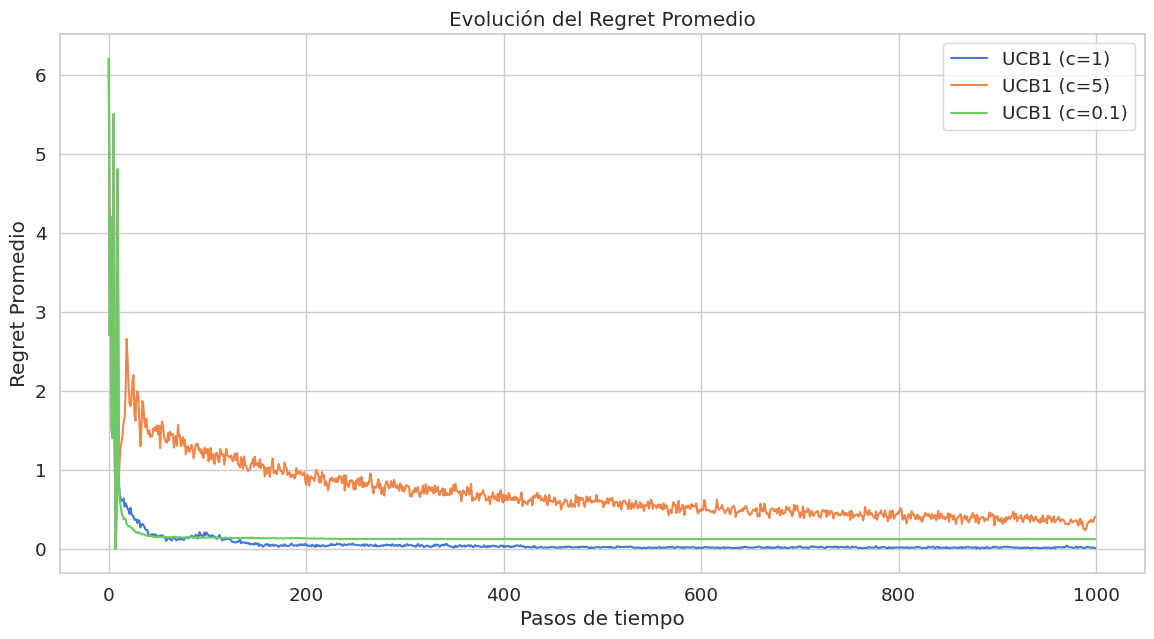

In [12]:
plot_regret(steps, regret_bi, algorithms)

**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función del número de pasos de tiempo para el algoritmo **UCB1** con diferentes valores del parámetro \( c \):

---

**Para \($c$ = 0.1\) – Baja Exploración**

- Regret inicial muy alto, con grandes oscilaciones.  
- Luego, desciende rápidamente y se estabiliza en un **regret acumulado bajo**.  
- Sin embargo, este comportamiento indica que la **exploración inicial es insuficiente**, lo que puede llevar a una mala identificación del brazo óptimo en algunos casos.  

**Para \($c$ = 5\) – Alta Exploración**   
- Regret inicial menor que \( c = 0.1 \), pero **permanece más alto durante más tiempo**.  
- Debido a la **exploración excesiva**, sigue eligiendo brazos subóptimos incluso cuando el mejor ya es evidente.  
- Como resultado, su **regret acumulado es el mayor en el largo plazo**, aunque mejora con el tiempo.  

**Para  \($c$ = 1\) – Exploración Equilibrada**
- **Regret inicial bajo y estable**, sin las oscilaciones abruptas de \( c = 0.1 \).  
- Se reduce rápidamente y **se mantiene en el menor nivel** en comparación con las otras configuraciones.  
- Representa el **mejor compromiso** entre exploración y explotación.  


## Experimento UCB1 con brazos que siguen una distribución de probabilidad bernoulli

In [13]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, seed = SEED))# Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k), UCB1(k=k, c=5), UCB1(k=k, c=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections_be, regret_be = run_experiment_ucb1(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.25), ArmBernoulli(p=0.6), ArmBernoulli(p=0.45), ArmBernoulli(p=0.72), ArmBernoulli(p=0.73), ArmBernoulli(p=0.32), ArmBernoulli(p=0.74), ArmBernoulli(p=0.87), ArmBernoulli(p=0.8), ArmBernoulli(p=0.39)
Optimal arm: 8 with expected reward=0.87


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

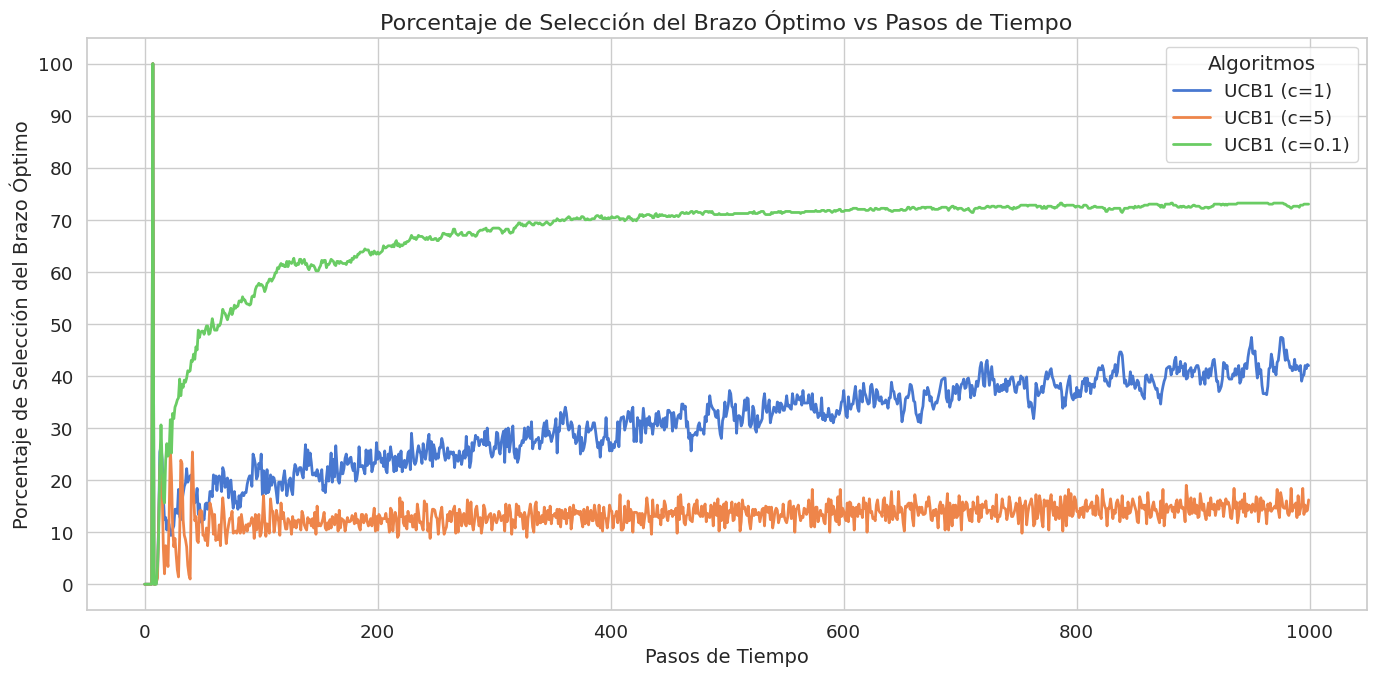

In [14]:
plot_optimal_selections(steps, optimal_selections_be, algorithms)

**Análisis**

El gráfico muestra la evolución del **porcentaje de selección del brazo óptimo** en función del tiempo para tres configuraciones del algoritmo **UCB1** con diferentes valores del parámetro \( c \).

---

**1. Cómo afectan los distintos valores de $c$**  

- **Azul ($c$ = 1)**
  - Se observa un una curva de aprendizaje más lenta que para otras distribuciones probabilisticas.  
  - Después de los primeros 1000 pasos la selección del brazo óptimo sigue aumentando y muestra potencial de mejora.    

- **Naranja ($c$ = 5)**
  - El porcentaje de selección del brazo óptimo es bajo y fluctuante, sin una tendencia clara de mejora.  
  - Permanece en torno al **10-15%**, lo que indica que el algoritmo sigue explorando otras opciones incluso cuando el mejor brazo ya es evidente.  
  - Esto confirma que una exploración excesiva impide la explotación eficiente del mejor brazo.  
  

- **Verde ($c$ = 0.1)**
  - Al inicio, el porcentaje de selección del brazo óptimo aumenta rápidamente.
  - Después de 200 pasos, supera el 50% y sigue aumentando hasta estabilizarse cerca del 70%.Conclusión: Este valor de c favorece más la explotación y permite encontrar el brazo óptimo de manera eficiente a corto plazo.


**2. Interpretación de los resultados**

**El equilibrio entre exploración y explotación es clave**  
- **un valor consistente** combina suficiente exploración inicial con una explotación eficiente del mejor brazo.  
- **un valor bajo encuentra rápido un buen brazo**, pero no explora lo suficiente para asegurarse de que sea el óptimo, en este caso para la distribución de probabilidad de bernoulli es una buena idea.  
- **un valor alto explora demasiado**, retrasando el aprendizaje del mejor brazo.  


#### Rechazo acumulado a lo largo del tiempo

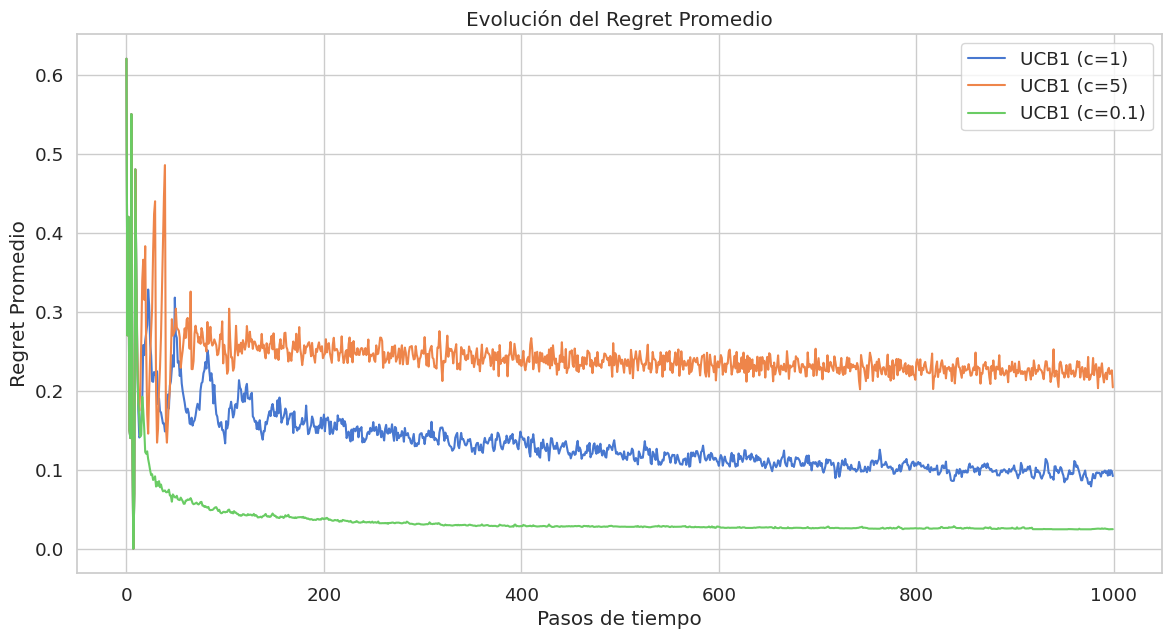

In [15]:
plot_regret(steps, regret_be, algorithms)

**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función del número de pasos de tiempo para el algoritmo **UCB1** con diferentes valores del parámetro \( c \):

---

**Para \($c$ = 0.1\) – Baja Exploración**

- Presenta un **pico inicial alto** debido a la incertidumbre en los primeros pasos.  
- Sin embargo, el regret cae **rápidamente** y se mantiene en valores bajos a lo largo del tiempo.  
- Esto indica que el algoritmo converge rápidamente hacia la explotación del mejor brazo.  


**Para \($c$ = 5\) – Alta Exploración**   
- Regret inicial menor que \( $c$ = 0.1 \), pero **permanece más alto durante más tiempo**.  
- Debido a la **exploración excesiva**, sigue eligiendo brazos subóptimos incluso cuando el mejor ya es evidente.  
- Como resultado, su **regret acumulado es el mayor en el largo plazo**, aunque mejora con el tiempo.  

**Para  \($c$ = 1\) – Exploración Equilibrada**
- **Regret inicial bajo y estable**, sin las oscilaciones abruptas de \( $c$ = 0.1 \).  
- Se reduce rápidamente y **se mantiene en el menor nivel** en comparación con las otras configuraciones.  
- Representa el **mejor compromiso** entre exploración y explotación.

## Conclusiones

Hemos estudiado el problema de toma de decisiones secuenciales utilizando el algoritmo **UCB1 (Upper Confidence Bound)** en el contexto de un **Multi-Armed Bandit (MAB)**. A partir de los resultados obtenidos y las gráficas analizadas hemos obtenido las siguientes conclusiones.



A diferencia del algoritmo **ε-Greedy**, que introduce exploración de manera aleatoria, **UCB1 ajusta dinámicamente la exploración en función de la incertidumbre de cada brazo**. Este mecanismo permite que el algoritmo explore más cuando la información es escasa y explote cuando tiene suficiente confianza en la mejor opción.  

- El párametro $c$ es crítico para el experimento porque es el que balancea la exploración con la explotación

- **UCB1 con ($c$ = 1, azul)** mostró el mejor desempeño, identificando rápidamente el brazo óptimo y manteniendo una alta selección del mismo a lo largo del tiempo, especialmente en distribuciones normales, donde alcanza un rendimiento casi perfecto después de 200 pasos. Además, la pérdida acumulada es baja, lo que indica una buena eficiencia en la toma de decisiones y un gran equilibrio entre exploración y explotación.  

- En distribuciones de bernoulli, el valor que mejor funciona es uno que explota más que explora por lo que parece que no es útil para este tipo de distribuciones en los que la recompensa es 0 o 1.

- Un valor de ($c$ > 1) hace que el algoritmo explore demasiado, lo que resulta en una baja selección inicial del brazo óptimo. Aunque la tasa de selección mejora con el tiempo, nunca alcanza el nivel de valores más bajos de $c$. Esto muestra que un $c$ demasiado alto retrasa la explotación del mejor brazo.

En conclusión, UCB1 es una estrategia efectiva para el problema del bandido multibrazo cuando se busca un equilibrio entre exploración y explotación. En distribuciones normales y binomiales, UCB1 logra identificar y explotar rápidamente el mejor brazo. Sin embargo, en distribuciones Bernoulli, su rendimiento disminuye debido a una exploración excesiva en las primeras etapas. En estos casos, métodos alternativos como Thompson Sampling podrían ser más adecuados.





# Experimentos para la familia de algoritmos UCB2  

La función genérica `run_experiment_ucb2` se utilizará para llevar a cabo los distintos experimentos con el algoritmo **UCB2**. Para ello, se define una clase `ucb2` que hereda de la clase `Algorithm`, en la cual se implementa la política de selección de brazo propia de UCB2.

La política de selección se basa en la siguiente ecuación:

$$
\text{UCB2}(a) = Q(a) + \sqrt{\frac{(1+\alpha)\ln\left(\frac{e \, t}{\tau(k_a)}\right)}{2\, \tau(k_a)}}
$$


El algoritmo **UCB2** difiere de **UCB1** en que divide el proceso de decisión en **épocas**. Para cada brazo $a$, se define el número de rondas que se jugará en la época actual mediante:

$$
\tau(k_a) = \lceil (1+\alpha)^{k_a} \rceil,
$$

donde **k_a** es el índice de la época actual para el brazo $a$. Durante cada bloque, el brazo seleccionado se juega repetidamente hasta completar $\tau(k_a)$ rondas, luego se actualizan sus estimaciones $(Q(a))$ y el contador $(k_a)$.

Este esquema permite que UCB2 ajuste dinámicamente el balance entre **exploración** y **explotación**:  
- La **explotación** se realiza a través de la estimación $Q(a)$.  
- La **exploración** se incorpora mediante el término de incertidumbre, que depende de $\tau(k_a)$ y del parámetro $\alpha$.




In [16]:
def run_experiment_ucb2(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Realiza simulaciones de un problema k-arm bandit con diferentes estrategias.

    :param bandit: Instancia del entorno de bandit.
    :param algorithms: Lista de algoritmos a evaluar.
    :param steps: Número de iteraciones en cada simulación.
    :param runs: Número de veces que se repite la simulación para promediar resultados.
    """
    optimal_arm = bandit.optimal_arm  # Índice del mejor brazo.

    optimal_picks = np.zeros((len(algorithms), steps))  # Registro de elecciones óptimas.
    regret = np.zeros((len(algorithms), steps))  # Registro de regret acumulado.

    for run in range(runs):
        simulation_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset()  # Restablecer valores del algoritmo antes de cada ejecución, importante sobre todo para las épocas de cada acción


        for idx, algo in enumerate(algorithms):
          step = 0
          while step < steps:
            if step < k: #inicializaciones iniciales (k actualizaciones, es decir, k pasos de tiempo)
              selected_arm = step
              reward = simulation_bandit.pull_arm(selected_arm)
              algo.update(selected_arm, reward, update_epoch = False)
              # Registrar selecciones óptimas y rechazos
              optimal_picks[idx, step] += (selected_arm == optimal_arm)
              regret[idx, step] += simulation_bandit.get_expected_value(optimal_arm) - simulation_bandit.get_expected_value(selected_arm)
              step += 1
            else:
              selected_arm, intervalo_temporal = algo.select_arm(step)
              horizonte_temporal = step + intervalo_temporal
              while step < horizonte_temporal and step < steps:
                  reward = simulation_bandit.pull_arm(selected_arm)
                  algo.update(selected_arm, reward, update_epoch = False)
                  # Registrar selecciones óptimas y rechazos
                  optimal_picks[idx, step] += (selected_arm == optimal_arm)
                  regret[idx, step] += simulation_bandit.get_expected_value(optimal_arm) - simulation_bandit.get_expected_value(selected_arm)
                  step += 1
              #Actualizamos el número de épocas de la acción, incrementando en 1 su valor
              algo.update(selected_arm, 0, update_epoch = True)




    # Promediar resultados sobre todas las simulaciones
    regret /= runs
    optimal_picks /= runs
    optimal_picks *= 100  # Convertir en porcentaje

    return optimal_picks, regret

## Experimento UCB2 con brazos que siguen una distribución de probabilidad normal

In [17]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB2(k=k, alpha=0.5), UCB2(k=k, alpha=0.1), UCB2(k=k, alpha=0.75)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_ucb2(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=2.72, sigma=1.0), ArmNormal(mu=3.45, sigma=1.0), ArmNormal(mu=4.94, sigma=1.0), ArmNormal(mu=3.49, sigma=1.0), ArmNormal(mu=6.6, sigma=1.0), ArmNormal(mu=8.07, sigma=1.0), ArmNormal(mu=8.02, sigma=1.0), ArmNormal(mu=8.22, sigma=1.0), ArmNormal(mu=9.62, sigma=1.0), ArmNormal(mu=8.88, sigma=1.0)
Optimal arm: 9 with expected reward=9.62


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

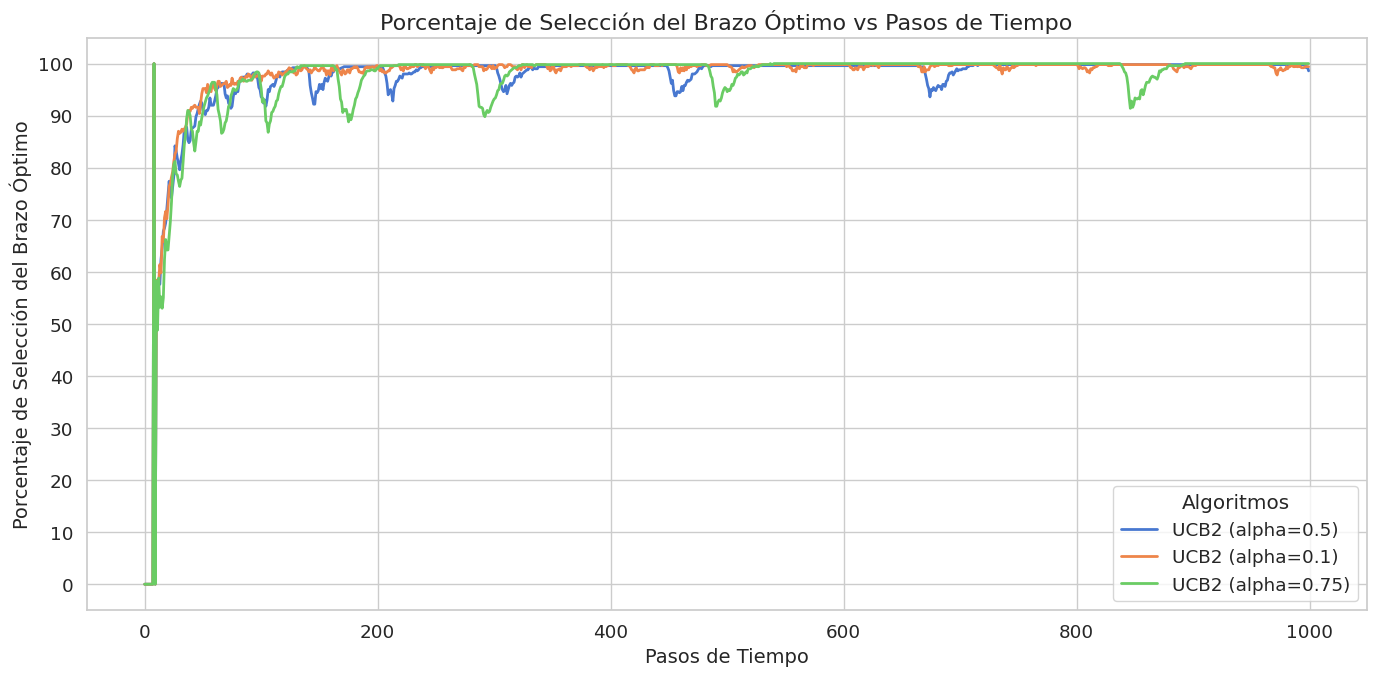

In [18]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

La imagen muestra un gráfico donde se analiza el rendimiento de diferentes variantes del algoritmo **UCB2** en un entorno de **multi-armed bandit**.

---

**1. Cómo afectan los distintos valores de $\alpha$**

- **Verde ($\alpha$ = 0.75)**
  - Exhibe **fluctuaciones** más marcadas en los primeros pasos de tiempo.
  - Aunque eventualmente converge a una alta tasa de selección del brazo óptimo, las caídas son más pronunciadas que en los otros casos.
  - un valor más alto genera **períodos de exlotación más largos**, lo que genera picos de baja selección del brazo óptimo antes de estabilizarse

- **Azul ($\alpha$  = 0.5)**
  - Inicialmente sigue una tendencia similar a  $\alpha$  = 0.1, pero presenta caídas periódicas en la selección del brazo óptimo.
  - Estas caídas indican que el algoritmo está realizando explotación cada cierto tiempo, realizando exploraciones en épocas más largas.
  - Mantiene un rendimiento aceptable sin inclinarse demasiado hacia la exploración o la explotación, el valor medio puede hacer que se revisiten brazos subóptimos.

- **Naranja ($\alpha$  = 0.1)**
  - Muestra una rápida convergencia hacia el brazo óptimo, con una curva ascendente muy estable.
  - Se mantiene cercano al 100% de selección del brazo óptimo, con pocas fluctuaciones.
  - **Explora menos**, alpha pequeño en UCB2 significa mayor agresividad en la exploración disminuyendo el tiempo de número de veces que una acción es seleccionada en un época.


**2. Interpretación de los resultados**

- **Exploración vs. Explotación en UCB2**  
  - Todas las variantes de UCB2 eventualmente logran seleccionar el brazo óptimo con alta frecuencia.
  - Sin embargo, **valores más altos de α generan exploraciones menos agresivas**, lo que provoca caídas en la tasa de selección del brazo óptimo antes de estabilizarse.
  - Un valor menor de $\alpha$ parece ser el valor más eficiente en términos de rápida convergencia y estabilidad en la selección del mejor brazo, diminuye el número de acciones por época.



#### Rechazo acumulado a lo largo del tiempo

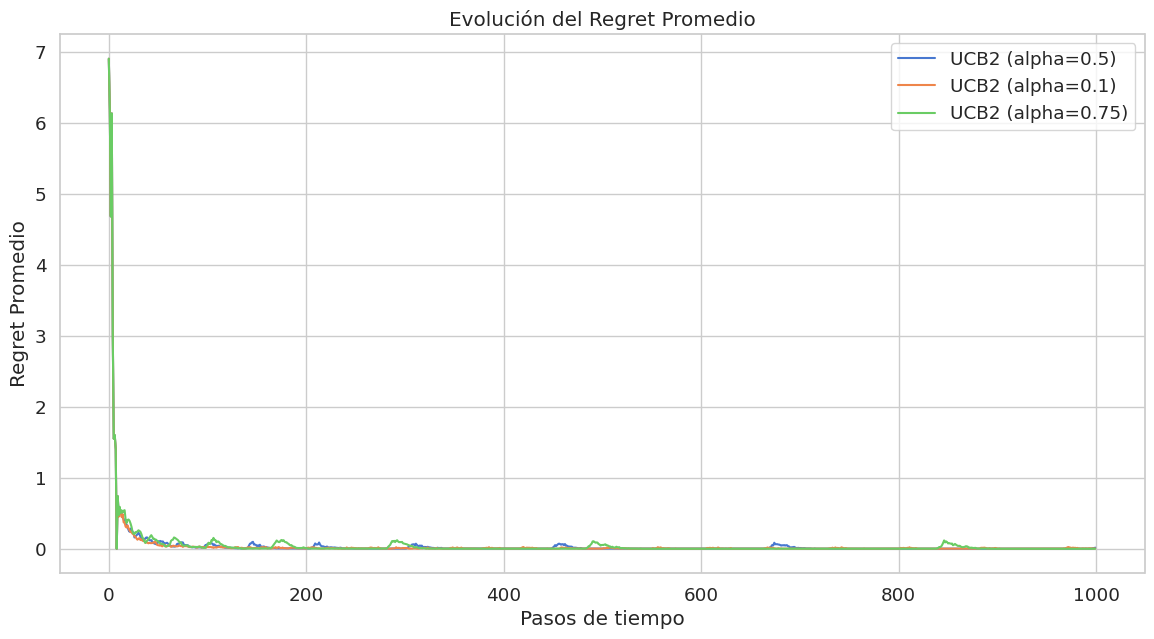

In [19]:
plot_regret(steps, regret, algorithms)


**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función de los pasos de tiempo para el algoritmo **UCB2** con tres valores distintos del parámetro **α**

---

### **1. Comportamiento según el valor de α**

#### **Para α = 0.75 (Verde) – épocas más largas**
- Observamos un regret muy bajo a partir de 10 pasos de tiempo entre 0 y 0.5.
- La exploración más lenta acaba siendo más segura para mayor número de pasos de tiempo.
#### **Para α = 0.5 (Azul) – Exploración Moderada**
- Observamos un regret muy bajo también, más o menos se sobrepone con la verde.
- La exploración lenta pero un poco más rápida que con 0.75 acaba siendo más segura a partir de los 650 pasos de tiempo.
#### **Para α = 0.1 (Naranja) – Alta Exploración**
- Observamos el mejor regret sobretodo para pasos de tiempo cercanos a 0.
- La exploración rápida permite obtenere el mejor brazo en el menor tiempo.



## Experimento UCB2 con brazos que siguen una distribución de probabilidad bernoulli

In [20]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, seed = SEED)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB2(k=k, alpha=0.5), UCB2(k=k, alpha=0.1), UCB2(k=k, alpha=0.75)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_ucb2(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.25), ArmBernoulli(p=0.6), ArmBernoulli(p=0.45), ArmBernoulli(p=0.72), ArmBernoulli(p=0.73), ArmBernoulli(p=0.32), ArmBernoulli(p=0.74), ArmBernoulli(p=0.87), ArmBernoulli(p=0.8), ArmBernoulli(p=0.39)
Optimal arm: 8 with expected reward=0.87


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

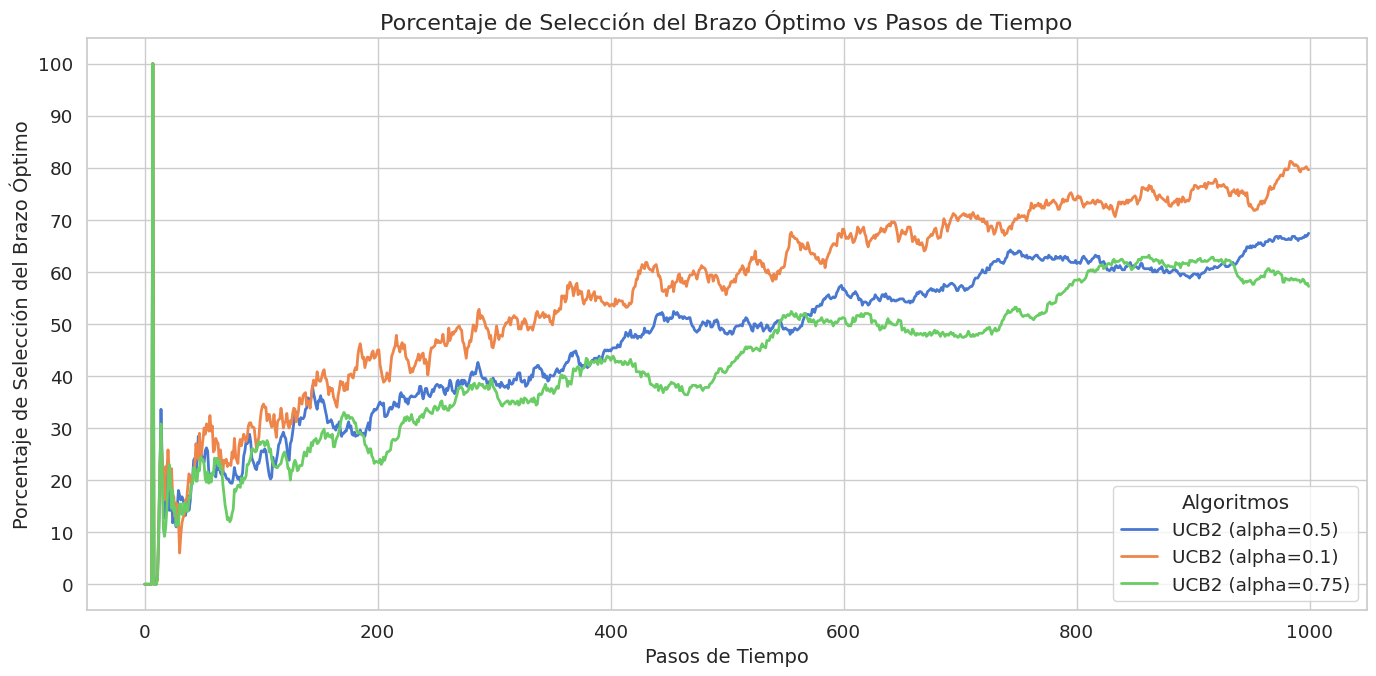

In [21]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

La imagen muestra un gráfico donde se analiza el rendimiento de diferentes variantes del algoritmo **UCB2** en un entorno de **multi-armed bandit**.

---

**1. Cómo afectan los distintos valores de $\alpha$**

- **Verde ($\alpha$ = 0.75)**
  - Vemos como el aprendizaje crece más despacio pero es más estable con el tiempo.
  - El algoritmo con este valor de alpha genera épocas mayores por lo que explora más lento.

- **Azul ($\alpha$  = 0.5)**
  - Con un valo de alpha un poco más bajo se ve que el comportamientoe similar para pocos pasos de tiempo y que se estabiliza antes que el un alpha mayor.
  - Alcanza valores de entre 60-70% por lo que no llega a consumir el brazo óptimo para todos los experimentos.

- **Naranja ($\alpha$  = 0.1)**
  - Es el que más rapido converge debido a que genera épocas más cortas y explorar más.
  - Alcanza un 80% de promedio de uso del brazo óptimo y continua su tendencia ascendente con el tiempo.


**2. Interpretación de los resultados**

- **Exploración vs. Explotación en UCB2**  
  - Todas las variantes de UCB2 para está distribución de probabilidada superan el 50% de utilidada del brazo óptimo.
  - Sin embargo, **valores más altos de α generan exploraciones menos agresivas**, lo que provoca caídas en la tasa de selección del brazo óptimo antes de estabilizarse.
  - Un valor menor de $\alpha$ parece ser el valor más eficiente en términos de rápida convergencia y estabilidad en la selección del mejor brazo, diminuye el número de acciones por época.


#### Rechazo acumulado a lo largo del tiempo

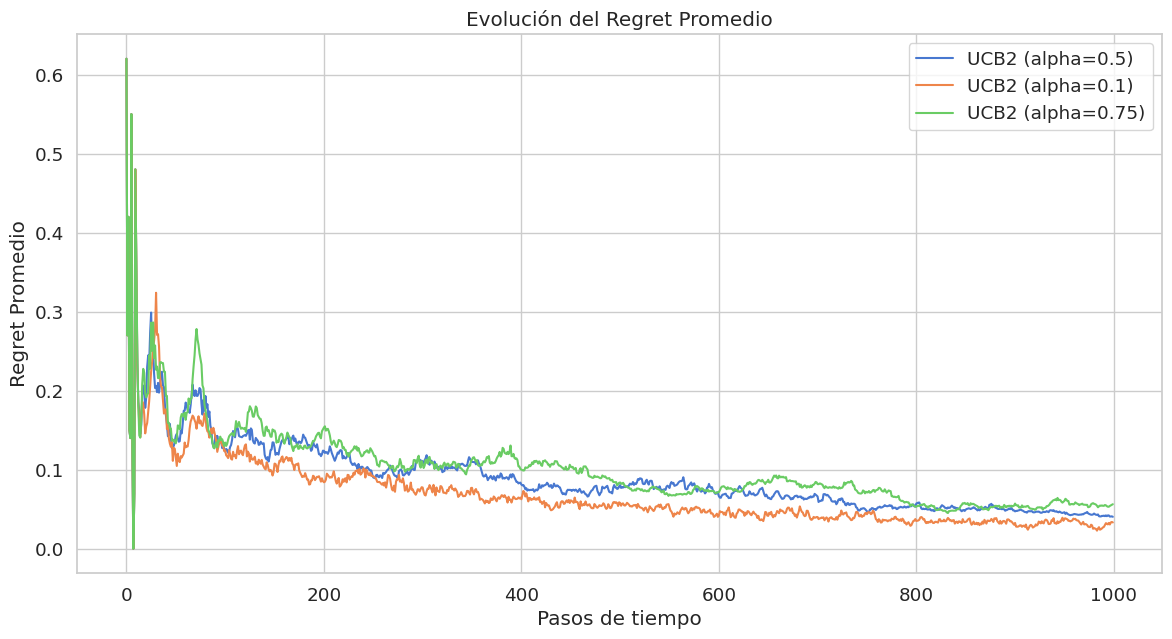

In [22]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función de los pasos de tiempo para el algoritmo **UCB2** con tres valores distintos del parámetro **α**

---

### **1. Comportamiento según el valor de α**

#### **Para α = 0.75 (Verde) – épocas más largas**
- Mayo regret inicial por lo que como hemos mencionado antes, se evidencia que el algoritmo tarda más en explotar el mejor brazo.
#### **Para α = 0.5 (Azul) – Exploración Moderada**
- Mejora el regret del α = 0.75 pero tambien tarda en explotar el mejor brazo.
#### **Para α = 0.1 (Naranja) – Alta Exploración**
- El regret disminuye rápidamente y se estabiliza en valores bajos, lo que sugiere una buena capacidad de identificación del mejor brazo.
- La exploración rápida permite encontrar rapidamente el brazo óptimo.

## Experimento UCB2 con brazos que siguen una distribución de probabilidad binomial

In [23]:
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n = 10, seed = SEED))
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB2(k=k, alpha=0.5), UCB2(k=k, alpha=0.1), UCB2(k=k, alpha=0.75)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
optimal_selections, regret = run_experiment_ucb2(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.45), ArmBinomial(n=10, p=0.72), ArmBinomial(n=10, p=0.73), ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.74), ArmBinomial(n=10, p=0.87), ArmBinomial(n=10, p=0.8), ArmBinomial(n=10, p=0.39)
Optimal arm: 8 with expected reward=8.7


### Visualización y análisis de resultados

#### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

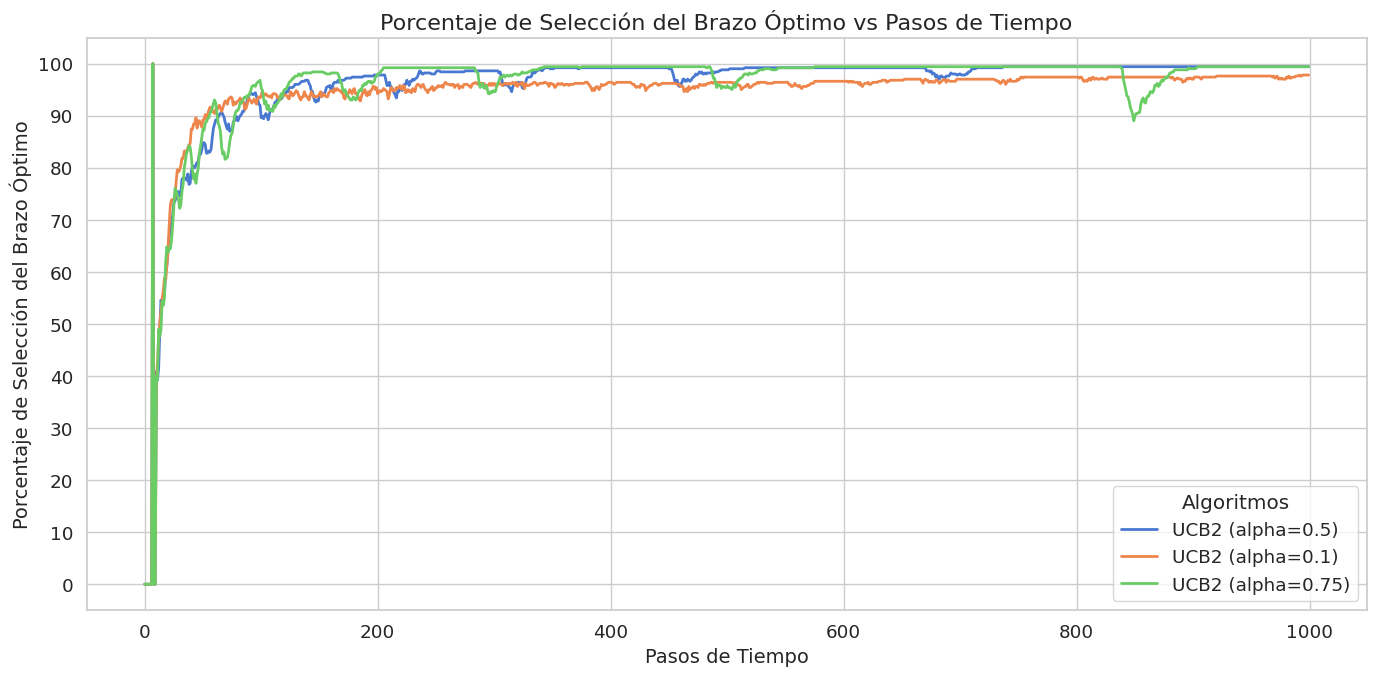

In [24]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis**

La imagen muestra un gráfico donde se analiza el rendimiento de diferentes variantes del algoritmo **UCB2** en un entorno de **multi-armed bandit**.

---

**1. Cómo afectan los distintos valores de $\alpha$**

- **Verde ($\alpha$ = 0.75)**
  - Muestra más fluctuaciones en la fase inicial y algunas caídas abruptas, lo que indica períodos más largos de exploración antes de estabilizarse.

- **Azul ($\alpha$  = 0.5)**
  - Tiene una convergencia razonablemente rápida, pero presenta algunas caídas debido a exploraciones periódicas.
- **Naranja ($\alpha$  = 0.1)**
  -  Converge rápidamente y mantiene una selección estable del brazo óptimo con pocas fluctuaciones. Explora menos tiempo.

**2. Interpretación de los resultados**

- **Exploración vs. Explotación en UCB2**  
  - Un α menor  favorece la explotación y alcanza estabilidad más rápido, mientras que valores más altos inducen exploración más prolongada y fluctuaciones en la selección óptima.

#### Rechazo acumulado a lo largo del tiempo

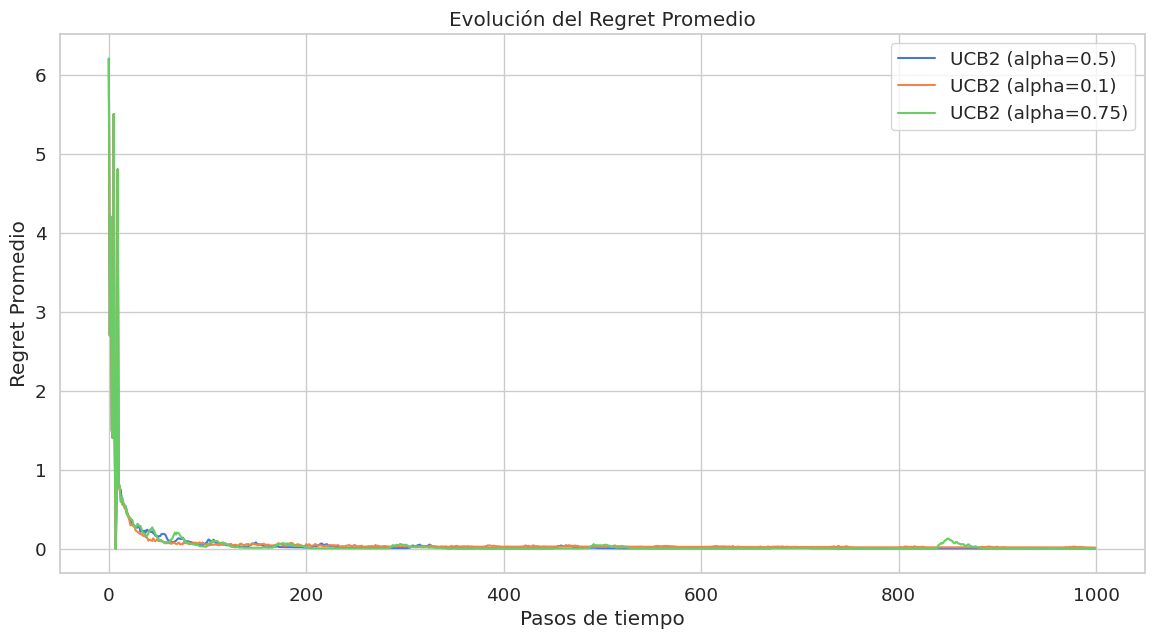

In [25]:
plot_regret(steps, regret, algorithms)

**Análisis**

El gráfico muestra la evolución del **regret acumulado** en función de los pasos de tiempo para el algoritmo **UCB2** con tres valores distintos del parámetro **α**

---

### **1. Comportamiento según el valor de α**

#### **Para α = 0.75 (Verde) – épocas más largas**
- La exploración más lenta acaba siendo más segura para mayor número de pasos de tiempo.
#### **Para α = 0.5 (Azul) – Exploración Moderada**
- Observamos un regret muy bajo también, más o menos se sobrepone con la verde.
- La exploración lenta pero un poco más rápida que con 0.75 acaba siendo más segura a partir de los 650 pasos de tiempo.
#### **Para α = 0.1 (Naranja) – Alta Exploración**
- Observamos el mejor regret sobretodo para pasos de tiempo cercanos a 0.
- La exploración rápida permite obtenere el mejor brazo en el menor tiempo.

## Conclusiones
Hemos estudiado el problema de toma de decisiones secuenciales utilizando el algoritmo **UCB2 (Upper Confidence Bound)** en el contexto de un **Multi-Armed Bandit (MAB)**. A partir de los resultados obtenidos y las gráficas analizadas hemos obtenido las siguientes conclusiones.



A diferencia del algoritmo **ε-Greedy**, que introduce exploración de manera aleatoria, **UCB2 organiza la exploración en épocas**, incrementando gradualmente la cantidad de veces que un brazo es seleccionado dentro de cada período. Este enfoque permite una exploración más eficiente, asegurando que los brazos prometedores sean evaluados durante intervalos crecientes antes de centrarse en la mejor opción conocida.


- El párametro $\alpha$ es crítico para el experimento porque es el que balancea la exploración con la explotación

- **UCB2 con ($\alpha$ = 0.1, naranja)** mostró el mejor desempeño, identificando rápidamente el brazo óptimo y manteniendo una alta selección del mismo a lo largo del tiempo, especialmente en distribuciones continuas o discretas con mayor granularidad (Normal y binomial)

- Un valor alto de ($\alpha > 0.5$) prolonga las épocas de exploración, lo que retrasa la explotación del mejor brazo y provoca fluctuaciones en la tasa de selección óptima. Aunque eventualmente converge, la estabilidad tarda más en alcanzarse.  

En conclusión, UCB2 es una estrategia efectiva para el problema del bandido multibrazo, ya que ajusta dinámicamente la exploración mediante épocas crecientes. Si la prioridad es converger rápidamente al mejor brazo, valores bajos de $\alpha$ (ej. 0.1) son ideales, pues reducen la exploración excesiva en las primeras etapas. En cambio, si se busca mantener exploración a lo largo del tiempo, valores intermedios como $\alpha = 0.5$ o $\alpha = 0.75$ pueden ser útiles, aunque con mayor fluctuación en la selección del brazo óptimo.
